# Import necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import utm
import math
import tensorflow as tf
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

ModuleNotFoundError: No module named 'tensorflow'

# Remove warning 

In [3]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [4]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [5]:
df.shape

(84593, 186)

# Feature Selection

In [6]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [7]:
df=df[features]

# Remove duplicate data points

In [8]:
# Remove duplicate rows and get the original DataFrame without duplicates
df_without_duplicates = df.drop_duplicates()
df=df_without_duplicates
df.shape

(77918, 11)

# Convert time string to seconds function

In [9]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Convert latitude and longitude into Cartesian coordinates

In [10]:
import pandas as pd
import math

# Define a function to convert latitude and longitude to local Cartesian coordinates
def convert_to_cartesian(row, origin_lat, origin_lon):
    # Calculate the differences between the current point and the origin
    delta_lat = row['OSD.latitude'] - origin_lat
    delta_lon = row['OSD.longitude'] - origin_lon
    
    # Convert the differences to meters using an appropriate conversion factor
    # For simplicity, assuming 1 degree of latitude = 111.32 km and 1 degree of longitude = 111.32 km * cos(latitude)
    lat_to_m = 111320.0  # meters per degree of latitude at the equator
    lon_to_m = 111320.0 * abs(math.cos(math.radians(origin_lat)))  # meters per degree of longitude
    
    # Calculate the x and y coordinates in meters
    x = delta_lon * lon_to_m
    y = delta_lat * lat_to_m
    
    return pd.Series([x, y])  # Return a Series with two values

# Assume 'df' is your DataFrame with columns 'OSD.latitude' and 'OSD.longitude'
# Define your local projection origin point
origin_lat = df['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df[['local_x', 'local_y']] = df.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Scale the Cartesian coordinates between -1 and 1 using Min-Max scaling
df['OSD.latitude'] = 2 * (df['local_x'] - df['local_x'].min()) / (df['local_x'].max() - df['local_x'].min()) - 1
df['OSD.longitude'] = 2 * (df['local_y'] - df['local_y'].min()) / (df['local_y'].max() - df['local_y'].min()) - 1

# Drop the 'local_x' and 'local_y' columns
df.drop(columns=['local_x', 'local_y'], inplace=True)

# Print the DataFrame
df.head()


,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,0.999882,0.999001,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [11]:
null_counts = df.isnull().sum(axis=0)
print(null_counts)

OSD.flyTime        0
RC.aileron         0
RC.elevator        0
RC.throttle        0
RC.rudder          0
OSD.longitude      0
OSD.latitude       0
OSD.height [ft]    0
OSD.pitch          0
OSD.roll           0
OSD.yaw            0
dtype: int64


## Identify Outliers

# Handle the Outliers

In [12]:
def two_sided_median_filter(data, window_size):
    """
    Perform two-sided median filtering for outlier detection.

    Parameters:
    - data: 1D numpy array containing the flight data
    - window_size: Size of the window for median filtering

    Returns:
    - filtered_data: Numpy array with outliers replaced by the median value of neighboring elements
    """
    filtered_data = np.zeros_like(data)
    half_window = window_size // 2

    for i in range(len(data)):
        lower_bound = max(0, i - half_window)
        upper_bound = min(len(data), i + half_window + 1)

        window = data[lower_bound:upper_bound]
        if len(window) > 0:  # Check if window is not empty
            median = np.median(window)

            if data[i] < median - 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            elif data[i] > median + 1.5 * np.median(np.abs(window - median)):
                filtered_data[i] = median
            else:
                filtered_data[i] = data[i]
        else:
            # If window is empty, set the filtered value to the original value
            filtered_data[i] = data[i]

    return filtered_data


# Apply two-sided median filtering to each feature
window_size = 7  # You can adjust the window size as needed
for feature in features:
    df[feature + '_filtered'] = two_sided_median_filter(df[feature].values, window_size)
    
# Calculate residuals
residuals = np.abs(df[feature] - df[feature + '_filtered'])

# Define threshold (e.g., based on median absolute deviation)
median_absolute_deviation = np.median(residuals)
threshold = 3 * median_absolute_deviation  # Adjust multiplier as needed

# Identify outliers
outliers = df[residuals > threshold]

# Filter outliers
filtered_df = df[residuals <= threshold]

# Display the shape of the filtered DataFrame before and after removing outliers
print("Shape of original DataFrame:", df.shape)
print("Shape of filtered DataFrame (after removing outliers):", filtered_df.shape)

Shape of original DataFrame: (77918, 22)
Shape of filtered DataFrame (after removing outliers): (70086, 22)


In [13]:
df=filtered_df
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,0.1,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,0.999882,0.999002,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
5,0.5,1024,1024,1024,1024,0.999881,0.999002,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
84587,614.6,1024,1024,364,1024,-0.998368,-0.990697,1.6,5.2,0.0,-81.4
84588,614.7,1024,1024,364,1024,-0.998369,-0.990697,1.6,6.0,-0.4,-81.7
84589,614.8,1024,1024,364,1024,-0.998369,-0.990697,1.6,6.4,-0.4,-82.6
84590,614.9,1024,1024,364,1024,-0.998369,-0.990698,1.6,6.8,-0.4,-83.1


# Normalize other features

In [14]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron','RC.elevator','RC.throttle','RC.rudder','OSD.longitude','OSD.latitude','OSD.height [ft]','OSD.pitch','OSD.roll','OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
1,-1.429326,0.0282,-0.525247,0.125785,-0.004928,5.681611,5.679521,-0.581177,1.171226,1.3949,1.190752
2,-1.428975,0.0282,-0.525247,0.125785,-0.004928,5.681609,5.679522,-0.581177,1.171226,1.3949,1.190752
3,-1.428625,0.0282,-0.525247,0.125785,-0.004928,5.681609,5.679522,-0.581177,1.171226,1.3949,1.190752
4,-1.428274,0.0282,-0.525247,0.125785,-0.004928,5.681608,5.679521,-0.581177,1.171226,1.3949,1.191839
5,-1.427923,0.0282,-0.525247,0.125785,-0.004928,5.681608,5.679522,-0.581177,1.171226,1.3949,1.191839


In [26]:
# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]


# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define a function to create the CNN model
def create_model(filters=64, kernel_size=3, activation='relu', optimizer='adam'):
    model = Sequential()
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation=activation, strides=1, padding='same', input_shape=(X_train.shape[1], 1)))  
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation=activation, padding='same'))
    model.add(Flatten())
    model.add(Dense(units=len(output_targets)))  # Output layer
    if optimizer == 'adam':
        optimizer = Adam()
    elif optimizer == 'rmsprop':
        optimizer = RMSprop()
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# Define the parameter grid
param_grid = {
    'filters': [32, 64, 128],
    'kernel_size': [3, 5],
    'activation': ['relu', 'tanh'],
    'optimizer': ['adam', 'rmsprop']
}

best_mse = np.inf
best_params = {}

# Perform grid search
for filters in param_grid['filters']:
    for kernel_size in param_grid['kernel_size']:
        for activation in param_grid['activation']:
            for optimizer in param_grid['optimizer']:
                print(f'Training model with filters={filters}, kernel_size={kernel_size}, activation={activation}, optimizer={optimizer}')
                model = create_model(filters=filters, kernel_size=kernel_size, activation=activation, optimizer=optimizer)
                model.fit(X_train_cnn, y_train, epochs=50, batch_size=32, verbose=0)
                mse = mean_squared_error(y_test, model.predict(X_test_cnn))
                if mse < best_mse:
                    best_mse = mse
                    best_params = {'filters': filters, 'kernel_size': kernel_size, 'activation': activation, 'optimizer': optimizer}

# Print the best parameters and best MSE
print("Best parameters found: ", best_params)
print("Best Mean Squared Error found: ", best_mse)

Training model with filters=32, kernel_size=3, activation=relu, optimizer=adam
439/439 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=3, activation=relu, optimizer=rmsprop
439/439 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=3, activation=tanh, optimizer=adam
439/439 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=3, activation=tanh, optimizer=rmsprop
439/439 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=5, activation=relu, optimizer=adam
439/439 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=5, activation=relu, optimizer=rmsprop
439/439 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=5, activation=tanh, optimizer=adam
439/439 [==============================] - 1s 2ms/step
Training model with filters=32, kernel_size=5, activa

In [16]:
# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reshape input data for CNN
X_train_cnn = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

# Define the CNN model with best parameters
model_cnn = Sequential()
model_cnn.add(Conv1D(filters=128, kernel_size=5, activation='relu', padding='same', input_shape=(X_train_cnn.shape[1], X_train_cnn.shape[2])))
model_cnn.add(Conv1D(filters=128, kernel_size=5, activation='relu', padding='same'))
model_cnn.add(Flatten())
model_cnn.add(Dense(units=len(output_targets)))  # Output layer



# Compile the model
model_cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
model_cnn.fit(X_train_cnn, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
mse_cnn = model_cnn.evaluate(X_test_cnn, y_test)

# Make predictions
y_pred_cnn = model_cnn.predict(X_test_cnn)

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom = mean_squared_error(y_test[target_variable], y_pred_cnn[:, i])
    r2_custom = r2_score(y_test[target_variable], y_pred_cnn[:, i])
    mae_custom = mean_absolute_error(y_test[target_variable], y_pred_cnn[:, i])
    variance_explained_custom = 100 * (1 - mse_custom / np.var(y_test[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error: {mse_custom:.2f}, R-squared: {r2_custom:.2%}, Mean Absolute Error: {mae_custom:.2f}, Variance Explained: {variance_explained_custom:.2f}%')

# Model Accuracy
print("CNN Model Accuracy:")
print(f"MSE: {mse_cnn}")


# Calculate average accuracy metrics
average_mse_cnn = np.mean([mean_squared_error(y_test[target_variable], y_pred_cnn[:, i]) for i, target_variable in enumerate(output_targets)])
average_r2_cnn = np.mean([r2_score(y_test[target_variable], y_pred_cnn[:, i]) for i, target_variable in enumerate(output_targets)])
average_mae_cnn = np.mean([mean_absolute_error(y_test[target_variable], y_pred_cnn[:, i]) for i, target_variable in enumerate(output_targets)])
average_variance_explained_cnn = np.mean([100 * (1 - mean_squared_error(y_test[target_variable], y_pred_cnn[:, i]) / np.var(y_test[target_variable])) for i, target_variable in enumerate(output_targets)])

# Print average accuracy metrics
print("Average Metrics for CNN Model:")
print(f"Mean Squared Error (MSE): {average_mse_cnn:.2f}")
print(f"R-squared: {average_r2_cnn:.2%}")
print(f"Mean Absolute Error (MAE): {average_mae_cnn:.2f}")
print(f"Variance Explained: {average_variance_explained_cnn:.2f}%")



Epoch 1/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.8311
Epoch 2/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.7738
Epoch 3/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.7507
Epoch 4/50
1753/1753 [==============================] - 10s 6ms/step - loss: 0.7387
Epoch 5/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.7301
Epoch 6/50
1753/1753 [==============================] - 10s 6ms/step - loss: 0.7228
Epoch 7/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.7163
Epoch 8/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.7098
Epoch 9/50
1753/1753 [==============================] - 10s 5ms/step - loss: 0.7066
Epoch 10/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.7011
Epoch 11/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.6964
Epoch 12/50
1753/1753 [==============================] - 9s 5ms/step - loss: 0.693

28/28 [==============================] - 0s 4ms/step
OSD.longitude - Mean Squared Error (CNN): 76.65, R-squared (CNN): -20.88%, Mean Absolute Error (CNN): 4.16, Variance Explained (CNN): -20.88%
OSD.latitude - Mean Squared Error (CNN): 35.16, R-squared (CNN): -7.07%, Mean Absolute Error (CNN): 3.29, Variance Explained (CNN): -7.07%
OSD.height [ft] - Mean Squared Error (CNN): 64.18, R-squared (CNN): -433.09%, Mean Absolute Error (CNN): 7.23, Variance Explained (CNN): -433.09%
OSD.pitch - Mean Squared Error (CNN): 10.60, R-squared (CNN): -0.09%, Mean Absolute Error (CNN): 2.36, Variance Explained (CNN): -0.09%
OSD.roll - Mean Squared Error (CNN): 14.94, R-squared (CNN): -38.69%, Mean Absolute Error (CNN): 2.56, Variance Explained (CNN): -38.69%
OSD.yaw - Mean Squared Error (CNN): 2868.58, R-squared (CNN): -10.40%, Mean Absolute Error (CNN): 35.96, Variance Explained (CNN): -10.40%


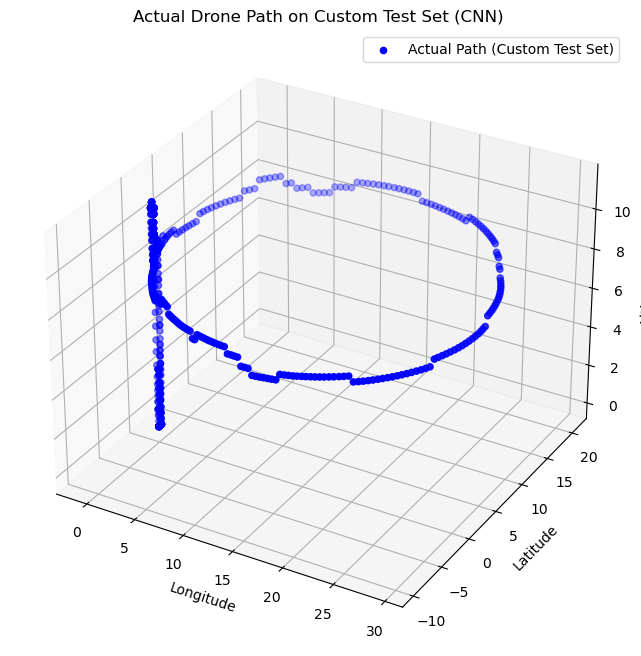

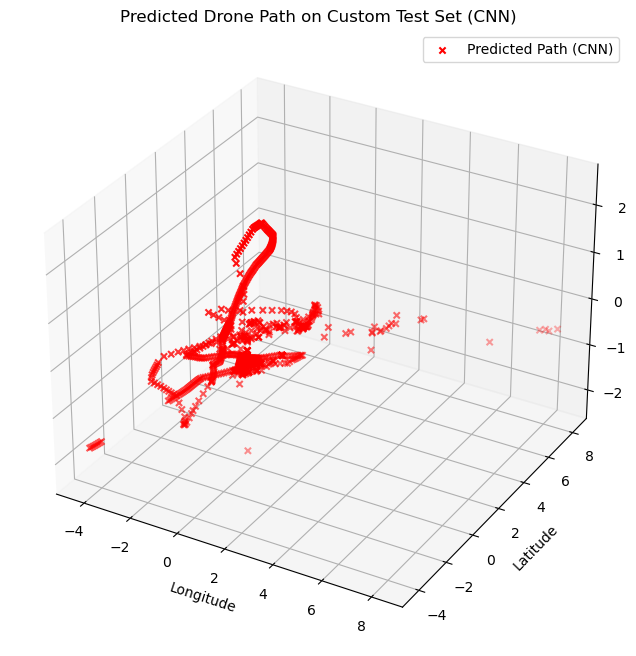

In [46]:
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Read the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Define your local projection origin point
origin_lat = df_test_custom['OSD.latitude'].iloc[0]  # Latitude of the first point in the DataFrame
origin_lon = df_test_custom['OSD.longitude'].iloc[0]  # Longitude of the first point in the DataFrame

# Apply the conversion function to each row and create new columns for local Cartesian coordinates
df_test_custom[['local_x', 'local_y']] = df_test_custom.apply(convert_to_cartesian, args=(origin_lat, origin_lon), axis=1)

# Keep the latitude and longitude columns and replace their values with 'local_x' and 'local_y' respectively
df_test_custom['OSD.latitude'] = df_test_custom['local_x']
df_test_custom['OSD.longitude'] = df_test_custom['local_y']

# Drop the 'local_x' and 'local_y' columns if needed
df_test_custom.drop(columns=['local_x', 'local_y'], inplace=True)


features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']
df_test_custom=df_test_custom[features]

# Normalization using StandardScaler
scaler = StandardScaler()
df_test_custom_scaled = scaler.fit_transform(df_test_custom)

X_test_custom_scaled = df_test_custom_scaled[:, :5]  # Select the first 5 columns after scaling

# Make predictions on the custom test set using the CNN model
y_pred_custom_cnn = model_cnn.predict(X_test_custom_scaled.reshape((X_test_custom_scaled.shape[0], X_test_custom_scaled.shape[1], 1)))

# Calculate and display accuracy metrics for each target variable on the custom test set
for i, target_variable in enumerate(output_targets):
    mse_custom_cnn = mean_squared_error(df_test_custom[target_variable], y_pred_custom_cnn[:, i])
    r2_custom_cnn = r2_score(df_test_custom[target_variable], y_pred_custom_cnn[:, i])
    mae_custom_cnn = mean_absolute_error(df_test_custom[target_variable], y_pred_custom_cnn[:, i])
    variance_explained_custom_cnn = 100 * (1 - mse_custom_cnn / np.var(df_test_custom[target_variable]))
    
    print(f'{target_variable} - Mean Squared Error (CNN): {mse_custom_cnn:.2f}, R-squared (CNN): {r2_custom_cnn:.2%}, Mean Absolute Error (CNN): {mae_custom_cnn:.2f}, Variance Explained (CNN): {variance_explained_custom_cnn:.2f}%')

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom_cnn = plt.figure(figsize=(12, 8))
ax_actual_custom_cnn = fig_actual_custom_cnn.add_subplot(111, projection='3d')
ax_actual_custom_cnn.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='blue', marker='o', label='Actual Path (Custom Test Set)')
ax_actual_custom_cnn.set_xlabel('Longitude')
ax_actual_custom_cnn.set_ylabel('Latitude')
ax_actual_custom_cnn.set_zlabel('Altitude (ft)')
ax_actual_custom_cnn.set_title('Actual Drone Path on Custom Test Set (CNN)')
ax_actual_custom_cnn.legend()

# Create a 3D plot for the predicted drone path on custom test set using the CNN model
fig_predicted_custom_cnn = plt.figure(figsize=(12, 8))
ax_predicted_custom_cnn = fig_predicted_custom_cnn.add_subplot(111, projection='3d')
ax_predicted_custom_cnn.scatter(y_pred_custom_cnn[:, 0], y_pred_custom_cnn[:, 1], y_pred_custom_cnn[:, 2], c='red', marker='x', label='Predicted Path (CNN)')
ax_predicted_custom_cnn.set_xlabel('Longitude')
ax_predicted_custom_cnn.set_ylabel('Latitude')
ax_predicted_custom_cnn.set_zlabel('Altitude (ft)')
ax_predicted_custom_cnn.set_title('Predicted Drone Path on Custom Test Set (CNN)')
ax_predicted_custom_cnn.legend()

# Show the actual and predicted path plots on the custom test set using the CNN model
plt.show()


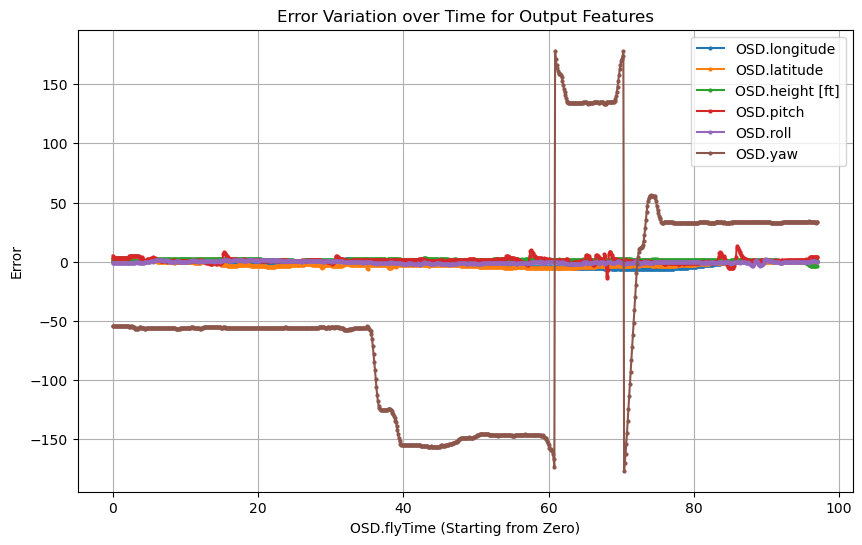

In [30]:
import matplotlib.pyplot as plt

# Calculate errors for each target variable
errors = df_test_custom[output_targets].to_numpy() - y_pred_custom_cnn

# Get OSD.flyTime values
fly_time = df_test_custom['OSD.flyTime']

# Subtract the minimum value of 'OSD.flyTime' from all time values to start from zero
fly_time_zero_start = fly_time - fly_time.min()

# Plot error variation over time for each output feature
plt.figure(figsize=(10, 6))
for i, target_feature in enumerate(output_targets):
    plt.plot(fly_time_zero_start, errors[:, i], marker='o', markersize=2, linestyle='-', label=target_feature)

plt.title('Error Variation over Time for Output Features')
plt.xlabel('OSD.flyTime (Starting from Zero)')
plt.ylabel('Error')
plt.grid(True)
plt.legend()
plt.show()


Epoch 1/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5634 - val_loss: 0.6067
Epoch 2/100
1753/1753 [==============================] - 11s 6ms/step - loss: 0.5654 - val_loss: 0.5998
Epoch 3/100
1753/1753 [==============================] - 10s 6ms/step - loss: 0.5639 - val_loss: 0.5960
Epoch 4/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5637 - val_loss: 0.6057
Epoch 5/100
1753/1753 [==============================] - 10s 6ms/step - loss: 0.5648 - val_loss: 0.5914
Epoch 6/100
1753/1753 [==============================] - 11s 6ms/step - loss: 0.5632 - val_loss: 0.6036
Epoch 7/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5635 - val_loss: 0.6033
Epoch 8/100
1753/1753 [==============================] - 10s 6ms/step - loss: 0.5637 - val_loss: 0.5961
Epoch 9/100
1753/1753 [==============================] - 12s 7ms/step - loss: 0.5620 - val_loss: 0.5957
Epoch 10/100
1753/1753 [==============================] - 9s 5ms/st

1753/1753 [==============================] - 9s 5ms/step - loss: 0.5540 - val_loss: 0.5925
Epoch 80/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5536 - val_loss: 0.5869
Epoch 81/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5517 - val_loss: 0.5923
Epoch 82/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5524 - val_loss: 0.6019
Epoch 83/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5534 - val_loss: 0.5909
Epoch 84/100
1753/1753 [==============================] - 9s 5ms/step - loss: 0.5532 - val_loss: 0.5907
Epoch 85/100
1753/1753 [==============================] - 10s 6ms/step - loss: 0.5536 - val_loss: 0.6035
Epoch 86/100
1753/1753 [==============================] - 10s 6ms/step - loss: 0.5520 - val_loss: 0.5944
Epoch 87/100
1753/1753 [==============================] - 10s 6ms/step - loss: 0.5531 - val_loss: 0.5893
Epoch 88/100
1753/1753 [==============================] - 10s 6ms/step - l

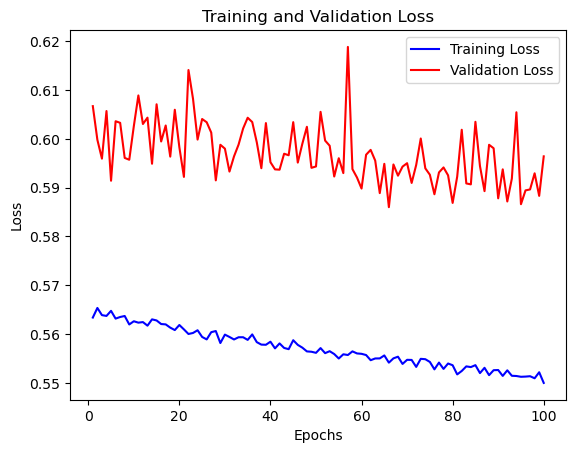

In [36]:
# Train the model
history = model_cnn.fit(X_train_cnn, y_train, epochs=100, batch_size=32, verbose=1, validation_data=(X_test_cnn, y_test))

# Extract loss values from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Plot the loss curve
plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


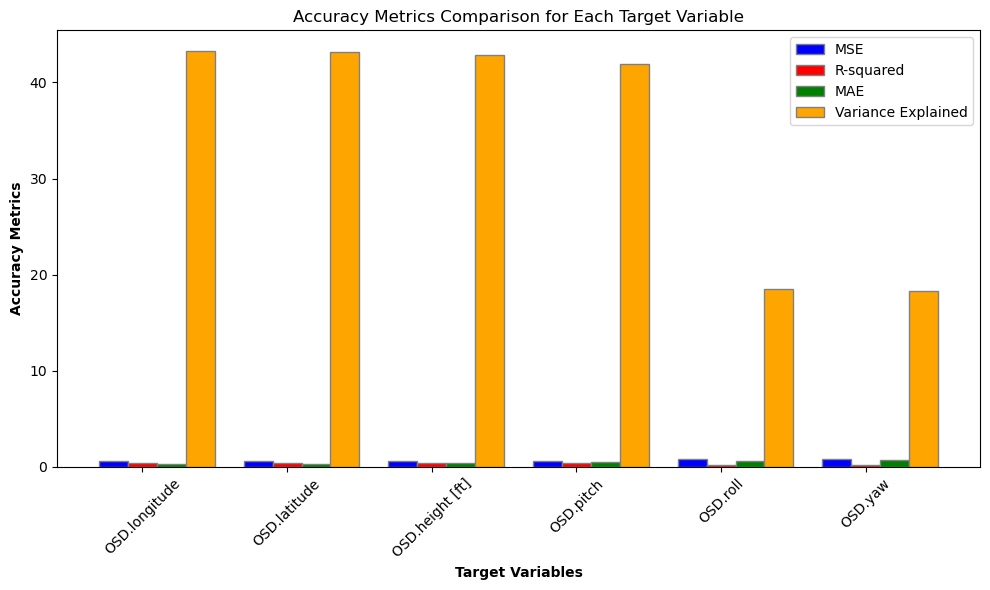

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate average accuracy metrics
average_metrics = {
    'MSE': average_mse_cnn,
    'R-squared': average_r2_cnn,
    'MAE': average_mae_cnn,
    'Variance Explained': average_variance_explained_cnn
}

# Target variables
target_variables = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Initialize lists to store metric values
mse_values = []
r2_values = []
mae_values = []
variance_explained_values = []

# Extract metric values for each target variable
for i, target_variable in enumerate(target_variables):
    mse_values.append(mean_squared_error(y_test[target_variable], y_pred_cnn[:, i]))
    r2_values.append(r2_score(y_test[target_variable], y_pred_cnn[:, i]))
    mae_values.append(mean_absolute_error(y_test[target_variable], y_pred_cnn[:, i]))
    variance_explained_values.append(100 * (1 - mean_squared_error(y_test[target_variable], y_pred_cnn[:, i]) / np.var(y_test[target_variable])))

# Set the width of the bars
bar_width = 0.2

# Set the positions of the bars on the x-axis
r1 = np.arange(len(target_variables))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]
r4 = [x + bar_width for x in r3]

# Create the bar chart
plt.figure(figsize=(10, 6))
plt.bar(r1, mse_values, color='b', width=bar_width, edgecolor='grey', label='MSE')
plt.bar(r2, r2_values, color='r', width=bar_width, edgecolor='grey', label='R-squared')
plt.bar(r3, mae_values, color='g', width=bar_width, edgecolor='grey', label='MAE')
plt.bar(r4, variance_explained_values, color='orange', width=bar_width, edgecolor='grey', label='Variance Explained')

# Add xticks on the middle of the group bars
plt.xlabel('Target Variables', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(target_variables))], target_variables, rotation=45)

# Add y label
plt.ylabel('Accuracy Metrics', fontweight='bold')

# Add a legend
plt.legend()

# Show the plot
plt.title('Accuracy Metrics Comparison for Each Target Variable')
plt.tight_layout()
plt.show()


In [44]:
# Extract metric values for each target variable
for i, target_variable in enumerate(target_variables):
    mse = mean_squared_error(y_test[target_variable], y_pred_cnn[:, i])
    r2 = r2_score(y_test[target_variable], y_pred_cnn[:, i])
    mae = mean_absolute_error(y_test[target_variable], y_pred_cnn[:, i])
    variance_explained = 100 * (1 - mean_squared_error(y_test[target_variable], y_pred_cnn[:, i]) / np.var(y_test[target_variable]))
    
    print(f"Target Variable: {target_variable}")
    print(f"MSE: {mse:.2f}")
    print(f"R-squared: {r2:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"Variance Explained: {variance_explained:.2f}%")
    print()


Target Variable: OSD.longitude
MSE: 0.58
R-squared: 0.43
MAE: 0.26
Variance Explained: 43.26%

Target Variable: OSD.latitude
MSE: 0.58
R-squared: 0.43
MAE: 0.26
Variance Explained: 43.20%

Target Variable: OSD.height [ft]
MSE: 0.59
R-squared: 0.43
MAE: 0.44
Variance Explained: 42.83%

Target Variable: OSD.pitch
MSE: 0.59
R-squared: 0.42
MAE: 0.47
Variance Explained: 41.91%

Target Variable: OSD.roll
MSE: 0.84
R-squared: 0.18
MAE: 0.60
Variance Explained: 18.49%

Target Variable: OSD.yaw
MSE: 0.81
R-squared: 0.18
MAE: 0.72
Variance Explained: 18.31%

